In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
data = pd.read_csv('heart.csv')

In [3]:
print(data.head())
print(data.info())

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       

In [4]:
missing_values = data.isna().sum()
print("Missing Values:")
print(missing_values)

Missing Values:
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64


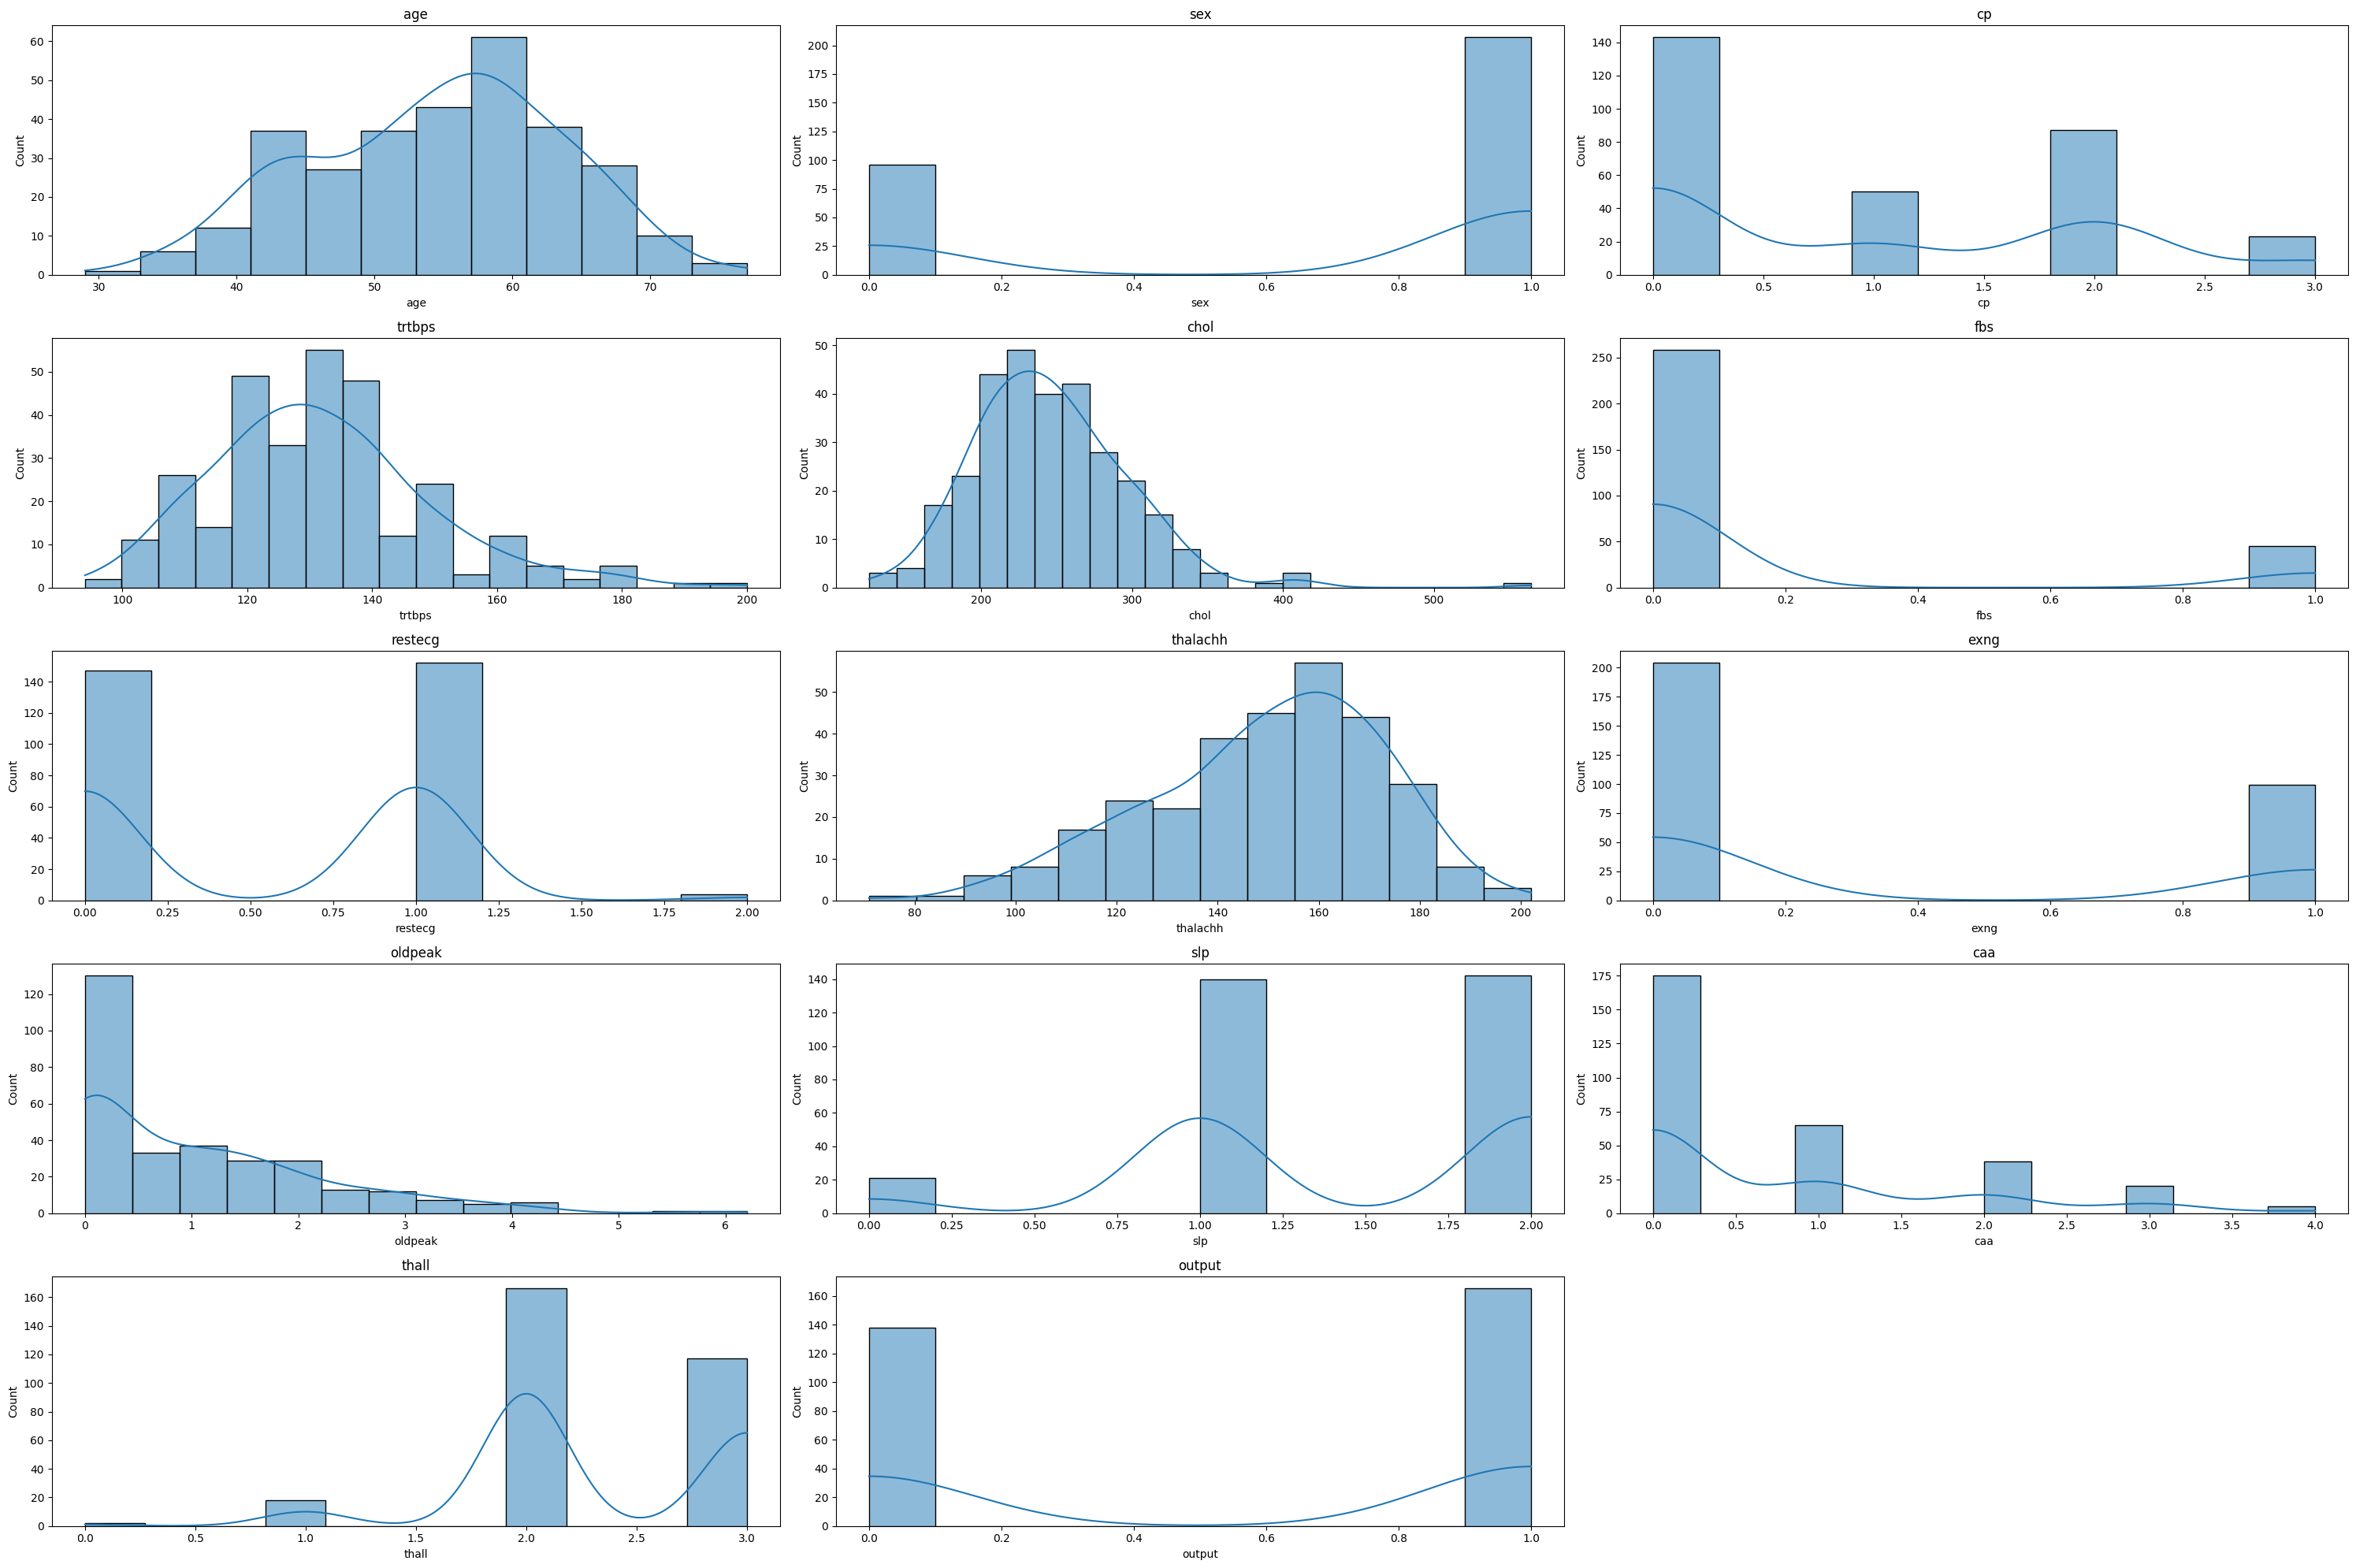

In [5]:
num_cols = len(data.columns) 
rows = math.ceil(num_cols / 3)
plt.figure(figsize=(30, 20))  
for i, col in enumerate(data.columns):  
    plt.subplot(rows, 3, i + 1)
    sns.histplot(data[col], kde=True)  
    plt.title(col)  
plt.tight_layout()  
plt.show() 

In [12]:
from sklearn.model_selection import train_test_split
X = data[['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak',  'caa','thall']] 
y = data['output']  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
from sklearn.preprocessing import StandardScaler  
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [18]:
scaler = StandardScaler()  
X_train = scaler.fit_transform(X_train)  
X_test = scaler.transform(X_test)  
models = {
       'SVM': SVC(probability=True),
       'Decision Tree': DecisionTreeClassifier(),
       'KNN': KNeighborsClassifier(),
       'Logistic Regression': LogisticRegression(max_iter=1000)  # افزایش max_iter در صورت نیاز
}
for name, model in models.items():
    model.fit(X_train, y_train)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    fn = confusion_matrix(y_test, y_pred)[1][0]  # False Negatives
    f2 = fbeta_score(y_test, y_pred, beta=2)
    print(f"F2 Score: {f2}, False Negatives: {fn}")
   

   

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73        28
           1       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61

F2 Score: 0.8284023668639053, False Negatives: 5
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.61      0.67        28
           1       0.71      0.82      0.76        33

    accuracy                           0.72        61
   macro avg       0.72      0.71      0.71        61
weighted avg       0.72      0.72      0.72        61

F2 Score: 0.7941176470588235, False Negatives: 6
KNN Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82     

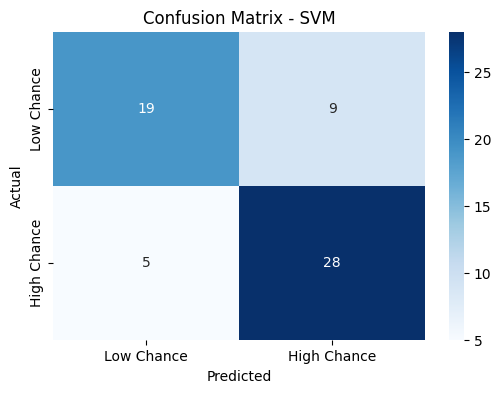

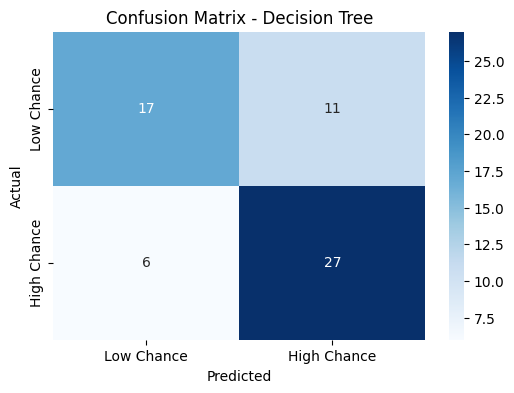

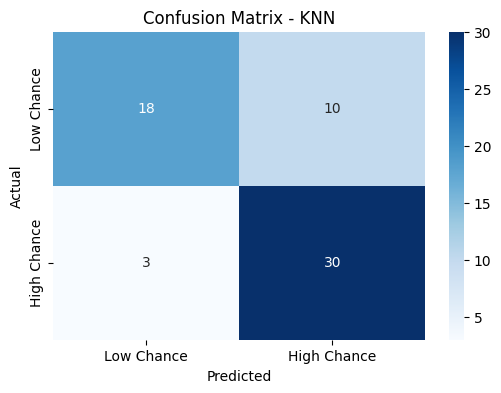

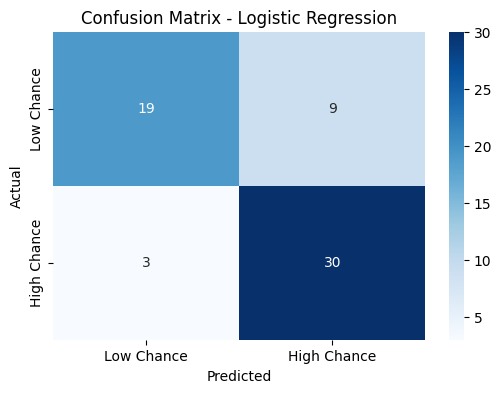

In [20]:
for name, model in models.items():  
    y_pred = model.predict(X_test)  
    conf_matrix = confusion_matrix(y_test, y_pred)  
    plt.figure(figsize=(6, 4))  
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',  
                xticklabels=['Low Chance', 'High Chance'],  
                yticklabels=['Low Chance', 'High Chance'])  
    plt.title(f'Confusion Matrix - {name}')  
    plt.xlabel('Predicted')  
    plt.ylabel('Actual')  
    plt.show() 